Key findings: (1) 26.6% overall churn rate — significant class imbalance. (2) Month-to-month customers churn at 42.7% vs 2.8% for 2-year contracts. (3) First 6 months is the highest-risk churn window at 55%. (4) Churned customers pay $13/month more on average, suggesting value perception is a key driver. (5) Class imbalance must be addressed before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print(df.shape)          
print(df.dtypes)         # column types
print(df.isnull().sum()) # missing values
df.head()

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Convert TotalCharges to numeric (blank strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 11 rows with missing TotalCharges (0.15% of data — safe to drop)
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df.shape)  # (7032, 21)

(7032, 21)


Churn Rate: 26.6%


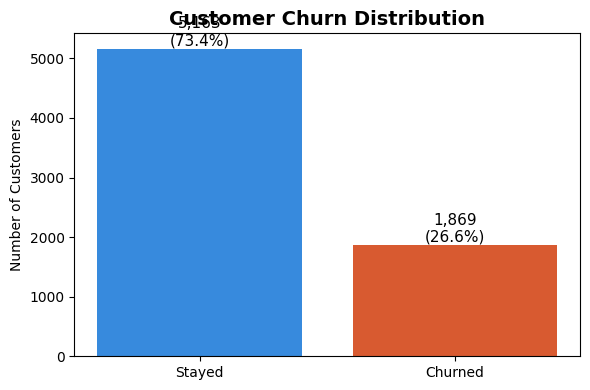

In [4]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].mean() * 100

print(f"Churn Rate: {churn_rate:.1f}%")
# Output: Churn Rate: 26.5%

# Plot it
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Stayed', 'Churned'], churn_counts.values, color=['#378ADD', '#D85A30'])
ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('charts/01_churn_distribution.png', dpi=150)
plt.show()

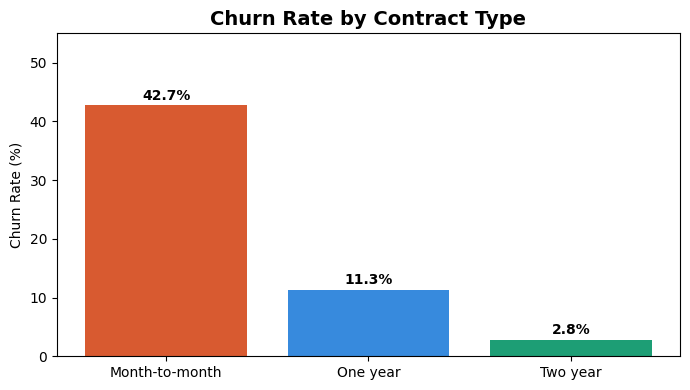

In [5]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#D85A30', '#378ADD', '#1D9E75'])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_churn_by_contract.png', dpi=150)
plt.show()

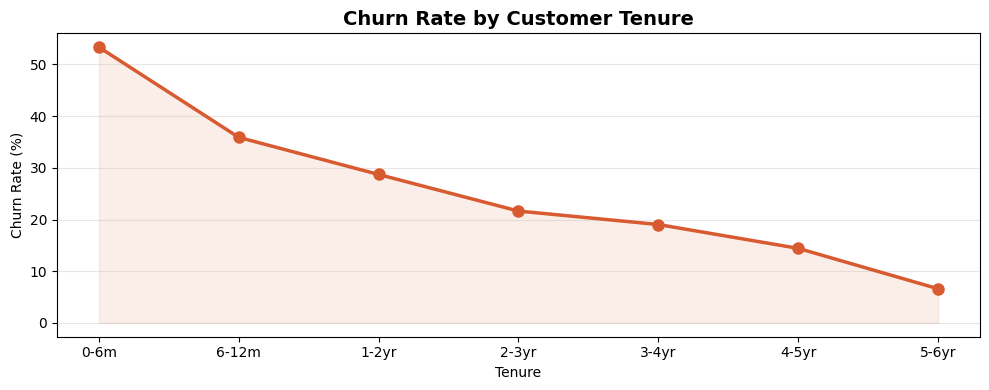

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
# Churn rate by tenure month buckets
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,6,12,24,36,48,60,72],
                              labels=['0-6m','6-12m','1-2yr','2-3yr','3-4yr','4-5yr','5-6yr'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].mean() * 100

ax.plot(tenure_churn.index, tenure_churn.values, marker='o',
        color='#D85A30', linewidth=2.5, markersize=8)
ax.fill_between(range(len(tenure_churn)), tenure_churn.values, alpha=0.1, color='#D85A30')
ax.set_title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/03_churn_by_tenure.png', dpi=150)
plt.show()

/var/folders/0l/6y_h81317nd3s25xnb5ft40h0000gn/T/ipykernel_6967/3219505035.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['Churn']==0]['MonthlyCharges'],


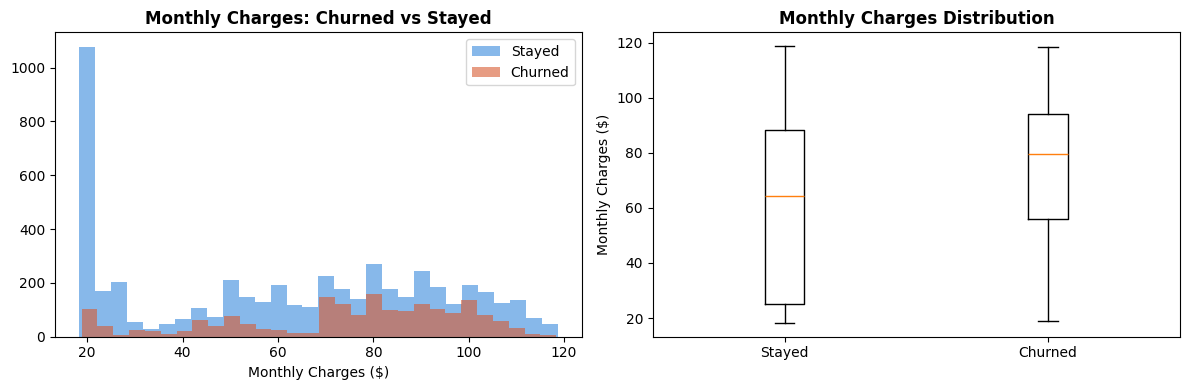

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution by churn
for churn_val, label, color in [(0, 'Stayed', '#378ADD'), (1, 'Churned', '#D85A30')]:
    axes[0].hist(df[df['Churn']==churn_val]['MonthlyCharges'],
                 bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title('Monthly Charges: Churned vs Stayed', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

# Box plot
df_plot = df.copy()
df_plot['Churn_label'] = df_plot['Churn'].map({0:'Stayed', 1:'Churned'})
axes[1].boxplot([df[df['Churn']==0]['MonthlyCharges'],
                 df[df['Churn']==1]['MonthlyCharges']],
                labels=['Stayed', 'Churned'])
axes[1].set_title('Monthly Charges Distribution', fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('charts/04_monthly_charges.png', dpi=150)
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].mean())

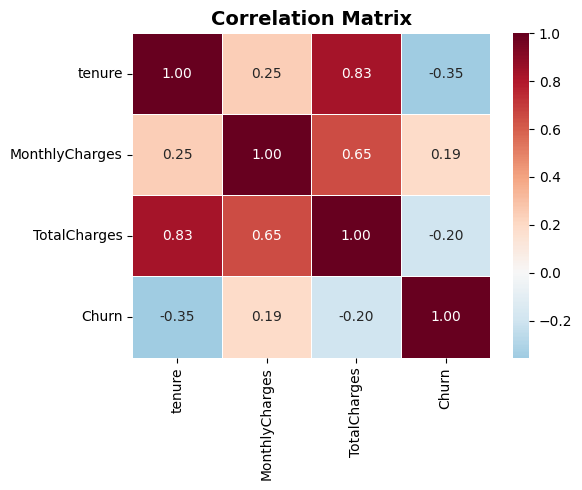

In [8]:
# Select numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
print("=" * 45)
print("CLASS IMBALANCE SUMMARY")
print("=" * 45)
print(f"Not Churned : {(df['Churn']==0).sum():,} ({(df['Churn']==0).mean()*100:.1f}%)")
print(f"Churned     : {(df['Churn']==1).sum():,} ({(df['Churn']==1).mean()*100:.1f}%)")
print()
print("Action: Will apply SMOTE oversampling in Phase 3")
print("Metric: Will use AUC-ROC + Recall, NOT accuracy")

CLASS IMBALANCE SUMMARY
Not Churned : 5,163 (73.4%)
Churned     : 1,869 (26.6%)

Action: Will apply SMOTE oversampling in Phase 3
Metric: Will use AUC-ROC + Recall, NOT accuracy
